In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('data_preprocessed.csv')
df = df.dropna(subset=['content_clean', 'sentimen_auto'])

X = df['content_clean']
y = df['sentimen_auto']

# Split SEBELUM vektorisasi (penting!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('Shape train:', X_train_tfidf.shape)
print('Shape test :', X_test_tfidf.shape)

Shape train: (3492, 500)
Shape test : (874, 500)


**Naive Bayes**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

pred_nb = nb_model.predict(X_test_tfidf)

print('=== NAIVE BAYES ===')
print(f'Akurasi: {accuracy_score(y_test, pred_nb):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, pred_nb))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, pred_nb))

=== NAIVE BAYES ===
Akurasi: 0.8043

Classification Report:
              precision    recall  f1-score   support

     negatif       0.73      0.52      0.60        95
      netral       0.46      0.28      0.35       134
     positif       0.85      0.96      0.90       645

    accuracy                           0.80       874
   macro avg       0.68      0.58      0.62       874
weighted avg       0.78      0.80      0.78       874


Confusion Matrix:
[[ 49  20  26]
 [ 13  37  84]
 [  5  23 617]]


**SVM**

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

pred_svm = svm_model.predict(X_test_tfidf)

print('=== SVM ===')
print(f'Akurasi: {accuracy_score(y_test, pred_svm):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, pred_svm))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, pred_svm))

=== SVM ===
Akurasi: 0.8524

Classification Report:
              precision    recall  f1-score   support

     negatif       0.77      0.74      0.75        95
      netral       0.55      0.49      0.51       134
     positif       0.92      0.95      0.93       645

    accuracy                           0.85       874
   macro avg       0.74      0.72      0.73       874
weighted avg       0.85      0.85      0.85       874


Confusion Matrix:
[[ 70  22   3]
 [ 18  65  51]
 [  3  32 610]]


**Save Model**

In [ ]:
import joblib

joblib.dump(svm_model, 'svm_sentiment.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print('Model dan vectorizer berhasil disimpan.')

Model dan vectorizer berhasil disimpan.


**Uji Model**

In [ ]:
import re

def preprocess_full(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z ]', '', text) # Remove punctuation and numbers, keep only letters and spaces
    return text.strip()

review_baru = [
    "Produknya sangat bagus, pengiriman cepat dan packing rapi",
    "Kecewa banget, barang rusak tidak sesuai foto",
    "Lumayan lah, sesuai harga"
]

review_clean = [preprocess_full(r) for r in review_baru]   # fungsi dari Tugas 3
review_vec   = tfidf.transform(review_clean)

print('Prediksi Naive Bayes:', nb_model.predict(review_vec))
print('Prediksi SVM        :', svm_model.predict(review_vec))

Prediksi Naive Bayes: ['positif' 'positif' 'positif']
Prediksi SVM        : ['positif' 'netral' 'netral']


**Data Test**

--- Informasi Dimensi Data ---
Shape train: (3492, 500)
Shape test : (874, 500)
----------------------------------------
Sistem: Model Naive Bayes berhasil dilatih menggunakan X_train_tfidf!
----------------------------------------
Akurasi Akhir Model Naive Bayes pada Data Test: 0.80
----------------------------------------
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

     negatif       0.73      0.52      0.60        95
      netral       0.46      0.28      0.35       134
     positif       0.85      0.96      0.90       645

    accuracy                           0.80       874
   macro avg       0.68      0.58      0.62       874
weighted avg       0.78      0.80      0.78       874

----------------------------------------
Visualisasi Confusion Matrix (Naive Bayes):


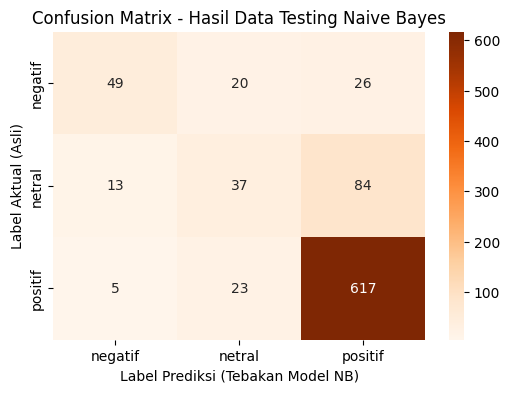

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. LOAD DATA DAN PREPARATION
# =========================================================================
df = pd.read_csv('data_preprocessed.csv')
df = df.dropna(subset=['content_clean', 'sentimen_auto'])

X = df['content_clean']
y = df['sentimen_auto']

# =========================================================================
# 2. SPLITTING DATA (80% Train, 20% Test)
# =========================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================================
# 3. VEKTORISASI TF-IDF
# =========================================================================
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('--- Informasi Dimensi Data ---')
print('Shape train:', X_train_tfidf.shape)
print('Shape test :', X_test_tfidf.shape)
print('-' * 40)

# =========================================================================
# 4. MEMBUAT DAN MELATIH MODEL NAIVE BAYES (MODEL TRAINING)
# =========================================================================
# Menggunakan Multinomial Naive Bayes yang cocok untuk data teks/distribusi frekuensi
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
print("Sistem: Model Naive Bayes berhasil dilatih menggunakan X_train_tfidf!")
print('-' * 40)

# =========================================================================
# 5. EVALUASI DAN DATA TESTING NAIVE BAYES
# =========================================================================
# Model melakukan prediksi langsung pada data test (20%)
y_pred_nb = model_nb.predict(X_test_tfidf)

# Menampilkan Skor Akurasi Akhir Naive Bayes
akurasi_nb = accuracy_score(y_test, y_pred_nb)
print(f"Akurasi Akhir Model Naive Bayes pada Data Test: {akurasi_nb:.2f}")
print('-' * 40)

# Menampilkan Classification Report Lengkap (Precision, Recall, F1-Score)
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print('-' * 40)

# Menampilkan Visualisasi Confusion Matrix untuk Naive Bayes
print("Visualisasi Confusion Matrix (Naive Bayes):")
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', # Menggunakan warna Oranges untuk membedakan dengan SVM
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix - Hasil Data Testing Naive Bayes')
plt.ylabel('Label Aktual (Asli)')
plt.xlabel('Label Prediksi (Tebakan Model NB)')
plt.show()

--- Informasi Dimensi Data ---
Shape train: (3492, 500)
Shape test : (874, 500)
----------------------------------------
Sistem: Model SVM berhasil dilatih menggunakan X_train_tfidf!
----------------------------------------
Akurasi Akhir Model pada Data Test: 0.86
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

     negatif       0.78      0.73      0.75        95
      netral       0.59      0.54      0.56       134
     positif       0.92      0.94      0.93       645

    accuracy                           0.86       874
   macro avg       0.76      0.74      0.75       874
weighted avg       0.85      0.86      0.85       874

----------------------------------------
Visualisasi Confusion Matrix:


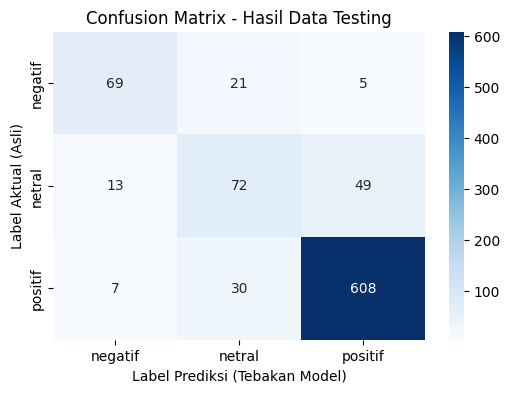

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. LOAD DATA DAN PREPARATION
# =========================================================================
df = pd.read_csv('data_preprocessed.csv')
df = df.dropna(subset=['content_clean', 'sentimen_auto'])

X = df['content_clean']
y = df['sentimen_auto']

# =========================================================================
# 2. SPLITTING DATA (80% Train, 20% Test)
# =========================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================================
# 3. VEKTORISASI TF-IDF
# =========================================================================
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('--- Informasi Dimensi Data ---')
print('Shape train:', X_train_tfidf.shape)
print('Shape test :', X_test_tfidf.shape)
print('-' * 40)

# =========================================================================
# 4. MEMBUAT DAN MELATIH MODEL (MODEL TRAINING)
# =========================================================================
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_tfidf, y_train)
print("Sistem: Model SVM berhasil dilatih menggunakan X_train_tfidf!")
print('-' * 40)

# =========================================================================
# 5. EVALUASI DAN DATA TESTING
# =========================================================================
# Model melakukan prediksi langsung pada data test
y_pred = model_svm.predict(X_test_tfidf)

# Menampilkan Skor Akurasi Akhir
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Akhir Model pada Data Test: {akurasi:.2f}")
print('-' * 40)

# Menampilkan Classification Report Lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred))
print('-' * 40)

# Menampilkan Visualisasi Confusion Matrix
print("Visualisasi Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title('Confusion Matrix - Hasil Data Testing')
plt.ylabel('Label Aktual (Asli)')
plt.xlabel('Label Prediksi (Tebakan Model)')
plt.show()